PneumoniaMNIST: analisi esplorativa dei dati 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

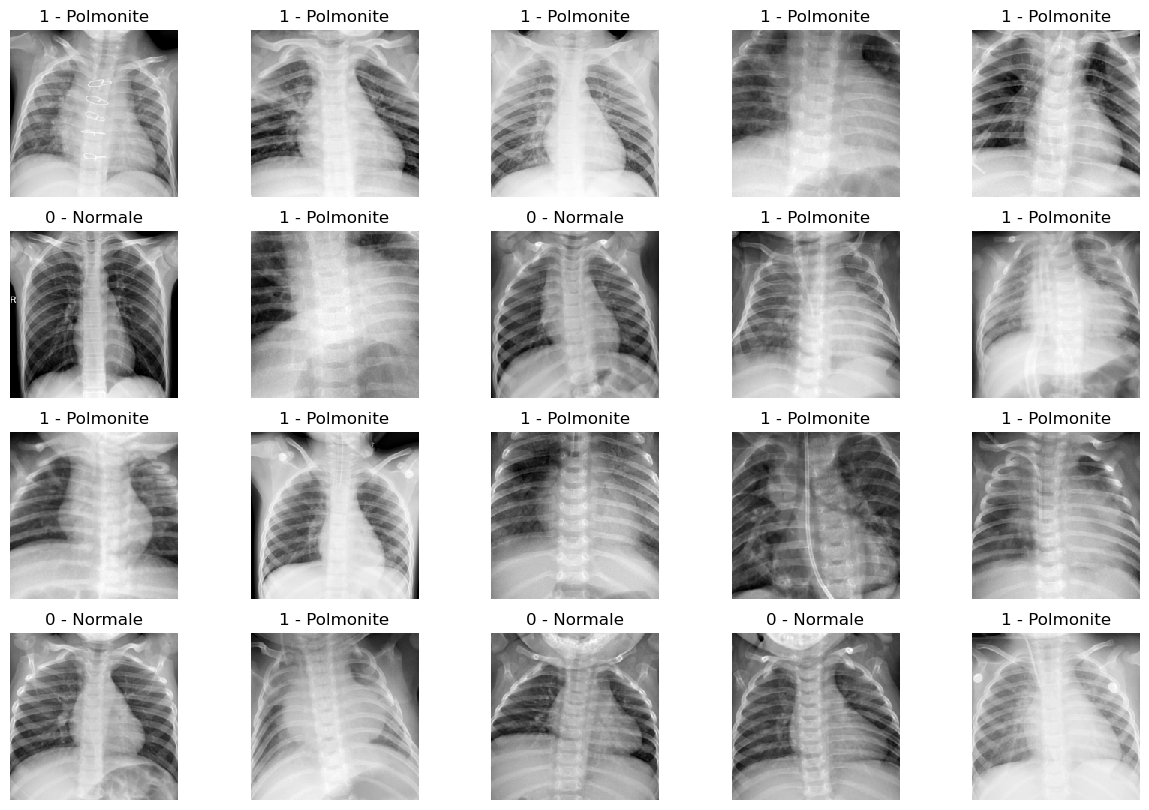

In [8]:
from medmnist import PneumoniaMNIST
import matplotlib.pyplot as plt

dataset=PneumoniaMNIST(split='train', download=True, size=224)

f=plt.figure(figsize=(15, 10))
count=1
dizionario={ 0:"0 - Normale", 1:"1 - Polmonite"}
for i in range(20):
    imarray=dataset[i][0] 
    label=dataset[i][1] 

    plt.subplot(4, 5, count) 
    count+=1

    plt.imshow(imarray, cmap='gray', interpolation='None')
    plt.title(dizionario[label[0]])
    plt.axis('off') 

plt.show()

Totale campioni: 4708
Classe 0 (Normal): 1214 (25.8%)
Classe 1 (Pneumonia): 3494 (74.2%)


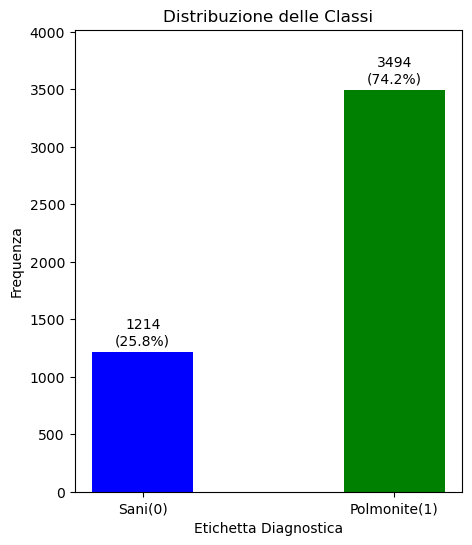

In [9]:
import matplotlib.pyplot as plt
import numpy as np

etichette=dataset.labels.squeeze()
classi,conteggi=np.unique(etichette, return_counts=True)

totale=sum(conteggi)
percentuali=(conteggi/totale)*100

print(f"Totale campioni: {totale}")
print(f"Classe 0 (Normal): {conteggi[0]} ({percentuali[0]:.1f}%)")
print(f"Classe 1 (Pneumonia): {conteggi[1]} ({percentuali[1]:.1f}%)")

testi_barre=[f"{c}\n({p:.1f}%)" for c, p in zip(conteggi, percentuali)]

nomi_barre=['Sani(0)', 'Polmonite(1)']
plt.figure(figsize=(5, 6))
barre=plt.bar(nomi_barre, conteggi, color=['blue', 'green'], width=0.4)

plt.bar_label(barre, labels=testi_barre, padding=3)

plt.title('Distribuzione delle Classi')
plt.ylabel('Frequenza')
plt.xlabel('Etichetta Diagnostica')

plt.ylim(0, max(conteggi) * 1.15) 
plt.show()

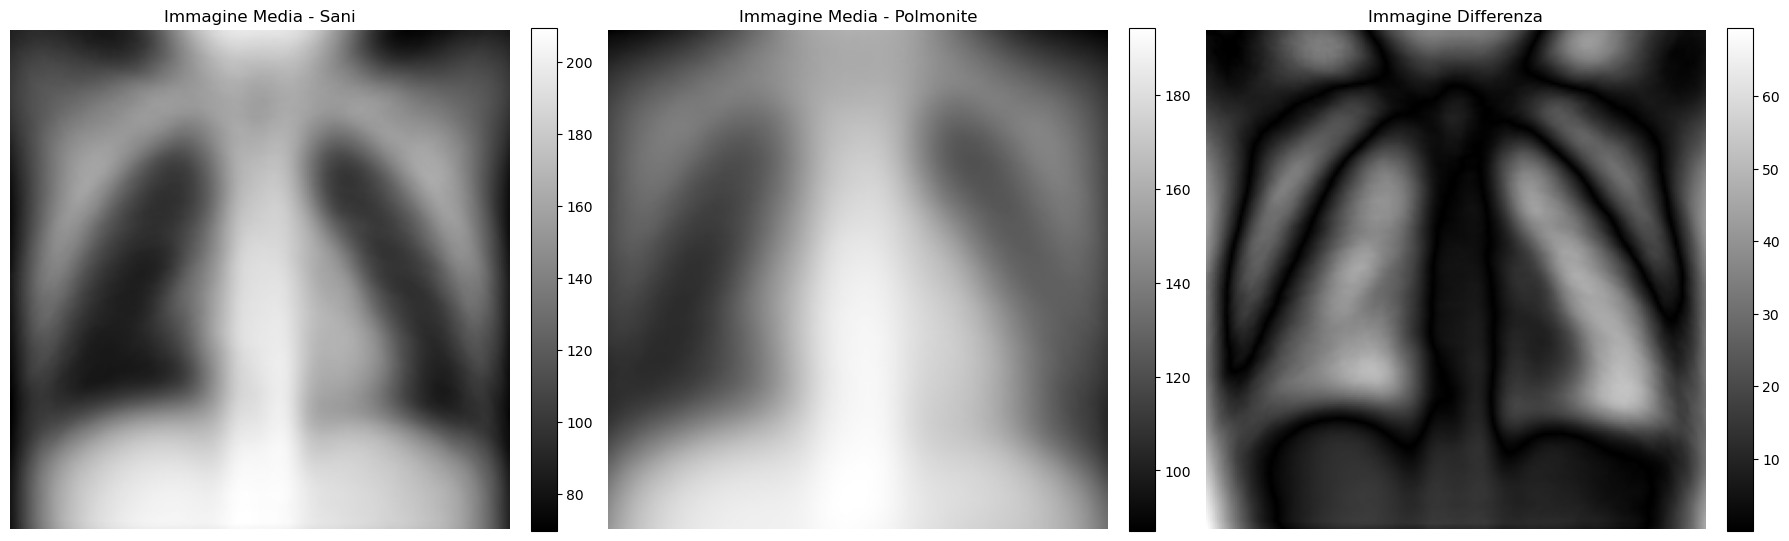

In [10]:
import numpy as np
import matplotlib.pyplot as plt


#1. CALCOLO DELLE MEDIE
immagini_sani=dataset.imgs[dataset.labels.squeeze() == 0]
immagini_polmonite=dataset.imgs[dataset.labels.squeeze() == 1]

media_sani=np.mean(immagini_sani, axis=0)
media_polmonite=np.mean(immagini_polmonite, axis=0)


# 2.CALCOLO DELL'IMMAGINE DI DIFFERENZA: usiamo il valore assoluto per catturare ogni variazione di luminosità
immagine_differenza=np.abs(media_polmonite - media_sani)

# 3.VISUALIZZAZIONE GRAFICI 
fig, axes=plt.subplots(1, 3, figsize=(18, 6))

#Media Sani
im1 = axes[0].imshow(media_sani, cmap='gray')
axes[0].set_title('Immagine Media - Sani')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

#Media Polmonite
im2 = axes[1].imshow(media_polmonite, cmap='gray')
axes[1].set_title('Immagine Media - Polmonite')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

#immagine differenza: usiamo la mappa di colore 'gray' essendo radiografie
im3 = axes[2].imshow(immagine_differenza, cmap='gray')
axes[2].set_title('Immagine Differenza')
axes[2].axis('off')
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

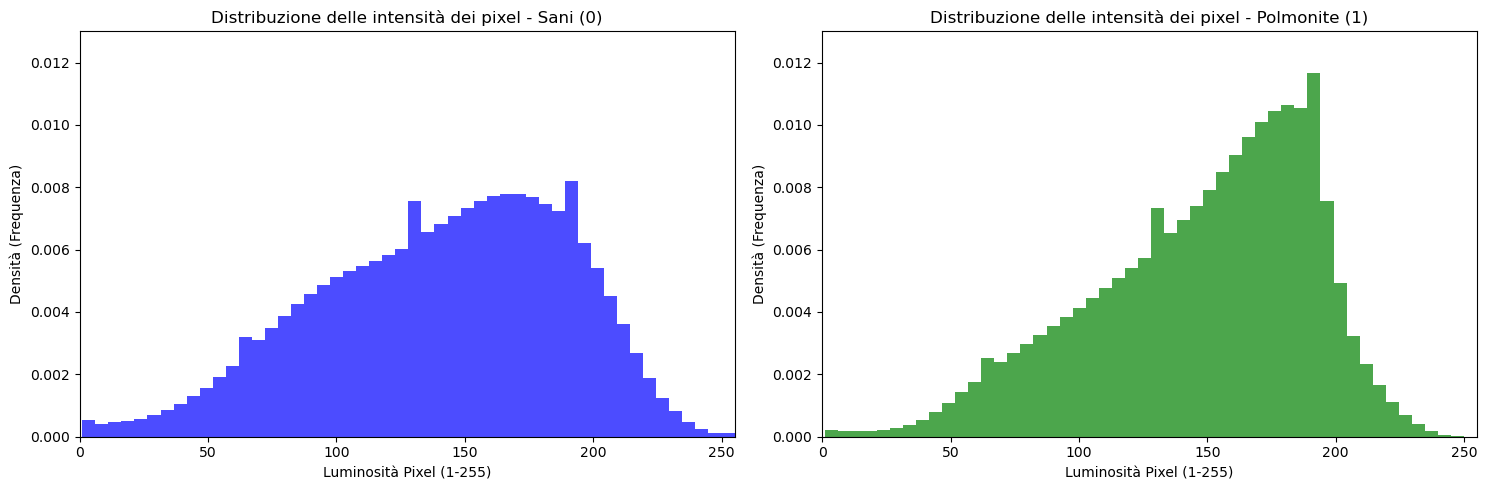

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

etichette=dataset.labels.squeeze()
immagini=dataset.imgs

#estraggo i pixel, rimuovo lo zero (sfondo) e appiattisco
pixel_sani=immagini[etichette == 0].flatten()
pixel_sani=pixel_sani[pixel_sani > 0]

pixel_polmonite=immagini[etichette == 1].flatten()
pixel_polmonite=pixel_polmonite[pixel_polmonite > 0]

#liste per ciclo
dati_classi=[pixel_sani,pixel_polmonite]
nomi_classi=['Sani (0)','Polmonite (1)']
colori=['blue', 'green']

#PLOT
f = plt.figure(figsize=(15, 5))
count = 1
for i in range(2): 
    plt.subplot(1, 2, count)
    count += 1
    
    plt.hist(dati_classi[i], bins=50, color=colori[i], density=True, alpha=0.7)
    
    #---PER LA STESSA SCALA---
    plt.ylim(0, 0.013)
    plt.xlim(0, 255)
    
    plt.title(f"Distribuzione delle intensità dei pixel - {nomi_classi[i]}")
    plt.xlabel("Luminosità Pixel (1-255)")
    plt.ylabel("Densità (Frequenza)")

plt.tight_layout()
plt.show()

In [12]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

trasformazione = transforms.Compose([ 
    transforms.ToTensor() #trasforma le foto PIL img, in tensori
])
train_set=PneumoniaMNIST(split='train',transform=trasformazione, download=True, size=224)
test_set=PneumoniaMNIST(split='test', download=True, size=224)
train_loader=DataLoader(dataset=train_set, batch_size=32, shuffle=True)
test_loader=DataLoader(dataset=test_set, shuffle=False)

immagini_batch,etichette_batch=next(iter(train_loader))

#stampiamo le dimensioni dei tensori
print("Forma del blocco immagini:",immagini_batch.shape)   
print("Forma del blocco etichette:",etichette_batch.shape) 

Forma del blocco immagini: torch.Size([32, 1, 224, 224])
Forma del blocco etichette: torch.Size([32, 1])


In [7]:
from medmnist import INFO

print(train_set)
print(f"Immagini per l'addestramento (Train): {len(train_set)}")
print(f"Immagini per la valutazione (Test): {len(test_set)}")

#MEDMNIST - Dettagli tecnici 
#la libreria ha un dizionario INFO con tutti i dettagli
dettagli = INFO['pneumoniamnist']
print(f"Descrizione: {dettagli['description']}")
print(f"Tipo di problema: {dettagli['task']}")
print(f"Canali immagine: {dettagli['n_channels']} (1 = Scala di grigi, 3 = Colori RGB)")
print(f"Significato Etichette: {dettagli['label']}")

Dataset PneumoniaMNIST of size 224 (pneumoniamnist_224)
    Number of datapoints: 4708
    Root location: /Users/rosachiara/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'normal', '1': 'pneumonia'}
    Number of samples: {'train': 4708, 'val': 524, 'test': 624}
    Description: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
    License: CC BY 4.0
Immagini per l'addestramento (Train): 4708
Immagini per la valutazione (Test): 624
Descrizione: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class class